<div align="center">
  <p><strong><a href="https://br.linkedin.com/in/isaac-maciel" target="_blank">Autor do Notebook: Isaac Maciel</a></strong></p>

<p align="center">
  <img src="https://github.com/IM-NOT-AI/IM-not-AI/assets/113378671/0a6e0c0f-fcdf-4ccc-af00-63e30836d180" alt="gif_isaac_nome" width="500">
</p>

In [37]:
%reload_ext watermark
%watermark -a "Isaac Maciel" -v -m
%watermark --iversions

Author: Isaac Maciel

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
CPU cores   : 16
Architecture: 64bit

matplotlib: 3.10.8
numpy     : 2.4.2
pandas    : 3.0.0
seaborn   : 0.13.2
sklearn   : 1.8.0



# PTB-XL EDA - Gêmeo Digital e Arquitetura Dual para Edge AI Cardíaco


### Imports & Leitura do CSV Base

In [9]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

# Remove o limite máximo de colunas exibidas
pd.set_option('display.max_columns', None)

In [10]:
BASE_DIR = Path.cwd().parent
PTB_DIR = BASE_DIR / "data" / "raw" / "ptbxl"

df = pd.read_csv(PTB_DIR / "ptbxl_database.csv")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  str    
 9   recording_date                21799 non-null  str    
 10  report                        21799 non-null  str    
 11  scp_codes                     21799 non-null  str    
 12  heart_axis                    13331 non-null  str    
 13  infarction_s

In [12]:
print(f"Dimensão do Dataset: {df.shape}")

Dimensão do Dataset: (21799, 28)


In [13]:
df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [14]:
df.tail()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
21794,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...",LAD,NaN,NaN,1.0,False,True,True,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr
21795,21834,20703.0,300.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",MID,Stadium II-III,NaN,1.0,False,True,True,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr
21796,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,"{'ISCAS': 50.0, 'SR': 0.0}",MID,NaN,NaN,1.0,True,True,True,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr
21797,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,supraventrikulÄre extrasystole(n) sinusrhythmu...,"{'NORM': 100.0, 'SR': 0.0}",LAD,NaN,NaN,1.0,False,True,True,NaN,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr
21798,21837,11744.0,68.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-11 16:43:01,sinusrhythmus p-sinistrocardiale lagetyp norma...,"{'NORM': 100.0, 'SR': 0.0}",MID,NaN,NaN,1.0,False,True,True,NaN,", I-AVL,",NaN,NaN,NaN,NaN,9,records100/21000/21837_lr,records500/21000/21837_hr


In [15]:
df.columns

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='str')

### Análise da Exploração Inicial

`Quais dados são relevantes para a Arquitetura?`

#### **Target (A "Fonte da Verdade")**
**scp_codes** (A Variável Alvo)
* Esta é a coluna vital do projeto. Ela contém o dicionário com os diagnósticos médicos estruturados (ex: infartos, arritmias, hipertrofias). É a partir dela que extrairemos as nossas Superclasses Preditivas, incluindo o mapeamento de incertezas para a classe de triagem médica.

#### **Features (Atributos Clínicos)**
**ecg_id** e **patient_id** (Índices de Isolamento)
* Totalmente preenchidos (21.799). São vitais para a estruturação do pipeline. Um mesmo paciente **_(patient_id)_** pode ter realizado múltiplos exames ao longo do tempo **_(ecg_id)._** O isolamento correto previne o temido *Data Leakage* (Vazamento de Dados), impedindo que a IA "decore" a assinatura elétrica do paciente ao invés de generalizar a patologia.

**age** e **sex** (Demografia e Contexto Fisiológico)
* Não possuem valores nulos e são a base do metabolismo clínico.
* **🚨 Alerta de Protocolo HIPAA:** O paciente 21834 (e vários outros) possui a idade cravada em **_300.0._** Isto não é um erro de digitação sistêmico. Para cumprir as normas internacionais de privacidade (HIPAA), indivíduos com idades superiores a 89 anos foram anonimizados desta forma. Para evitar o achatamento do teto de risco (onde a IA julgaria um centenário com o mesmo risco de um paciente de 89 anos), extrairemos uma feature explícita de incerteza **(idade_anonimizada_hipaa)** antes de normalizar este dado.

**strat_fold** (A Divisão Justa / Cross-Validation)
* Os autores do dataset do PhysioNet já forneceram esta coluna, que particiona os dados em 10 *folds* estratificados por paciente. Isso assegura que a nossa divisão de Treino, Validação e Teste siga o mais rigoroso padrão científico de auditoria.

**filename_lr** (O Mapa do Tesouro / 100Hz)
* O diretório que aponta para as matrizes **_.dat_** contendo o sinal elétrico puro. Utilizaremos estritamente a versão de 100Hz, otimizando o peso computacional para a futura implantação em Edge AI (Google Coral / Raspberry Pi) na beira do leito.

<br>

`Variáveis de Aprofundamento`

**Dados Esparsos** (Risco de Imputação Cega)
* **height** e **weight**: A Altura possui apenas 6.974 preenchimentos e o Peso 9.421. Faltam mais da metade dos registros biométricos. Realizar uma imputação artificial (preencher com a média) seria uma negligência clínica severa que inventaria o metabolismo de pacientes infartados. 
* **O Veredito:** Em vez de descartar as colunas, utilizaremos sua presença/ausência como o divisor de águas da nossa arquitetura dual (separando o Modelo Principal do Gateway de Triagem).

<br>

`Quais variáveis serão excluídas do Núcleo Principal?`

**Dados de Ruído Físico e Exceções (nfarction_stadium1, baseline_drift, pacemaker, etc.)**
* Possuem baixíssima incidência. O uso da flag **pacemaker** (marcapasso), por exemplo, induziria a rede convolucional ao *Shortcut Learning* (aprender a ler o pulso artificial da bateria do marcapasso ao invés da falha natural do músculo cardíaco).

**Metadados Administrativos (nurse, site, device, recording_date)**
* A Inteligência Artificial deve atuar na eletrofisiologia abstrata, independentemente se o exame foi realizado no hospital A ou B, na década de 90 ou hoje. Manter o enfermeiro ou a máquina no dataset cria viés de hardware e localidade.

**Dados Redundantes (report e filename_hr)**
* O **report** é o laudo em texto livre cru (muitas vezes em alemão). Como os especialistas já realizaram o parsing desse texto para a taxonomia formal da coluna **_scp_codes_**, o NLP (Processamento de Linguagem Natural) torna-se redundante. O **_filename_hr_** (500Hz) será descartado para evitar gargalos de processamento de I/O em dispositivos IoT.

<br>

`Fatos Analíticos (O Cenário Bruto)`

* **Fato 1:** A biometria completa (**_height_** e **_weight_** simultâneos) é extremamente rara na captura hospitalar real da época.
* **Fato 2:** Modelos profundos (Deep Learning) escalam a sua precisão com volumes massivos de dados estruturados.
* **Fato 3:** Se forçarmos a retenção apenas dos pacientes com anatomia e demografia 100% preenchidas (para fins de cálculos metabólicos precisos), o dataset encolherá violentamente de 21.799 para pouco mais de 6.660 exames clinicamente puros.

### Volume vs Densidade Informacional

Diante da esparsidade da Altura e do Peso (Fato 1 e 3) e da premissa de que modelos de Deep Learning geralmente exigem volumes massivos de exemplos para convergir (Fato 2), deparamo-nos com a decisão de modelagem mais crítica desta etapa: **Priorizar a retenção cega de linhas (Quantidade) ou a riqueza biológica (Qualidade)?**

Esta encruzilhada estatística levanta três questionamentos técnicos fundamentais para o sucesso do projeto:

1. **O Cenário de Extensão (Foco em Quantidade):** Se descartarmos as colunas de Altura e Peso para preservar a totalidade dos 21.799 pacientes em uma matriz única, qual será o limite matemático do nosso Feature Engineering e o impacto do nivelamento metabólico dos pacientes?
2. **O Cenário de Densidade (Foco em Qualidade):** Ao aceitarmos o sacrifício de isolar ≈ 70% do dataset na triagem para reter a integridade da Altura e do Peso no modelo principal (restando 6.665 exames completos), quão longe podemos expandir essa matriz horizontalmente através da criação de novas *Engineered Features* fisiológicas?
3. **O Veredito de Viabilidade Preditiva:** No balanço final das arquiteturas, o que é mais valioso para o motor do nosso algoritmo: um modelo único com alto volume de linhas (porém "míope" sobre a anatomia do paciente), ou um ecossistema dual (Modelo de Triagem + Modelo Principal de Alta Densidade) ciente das incertezas e com vasto contexto metabólico?

### Tratamento de Dados

#### Isolamento de Colunas e Remoção de Nulos

In [16]:
# Isolamento das covariáveis essenciais
clinical_features = [
    "ecg_id", "patient_id", "age", "sex", 
    "height", "weight", "strat_fold", 
    "filename_lr", "scp_codes"
]
df_curated = df[clinical_features].copy()

# A CRIAÇÃO DO GATEWAY DE CONFORMIDADE
# Em vez de dropar, vamos criar uma flag (máscara) de conformidade biométrica
mask_engineered = df_curated["height"].notnull() & df_curated["weight"].notnull()

# Rota A: O "Dataset de Engineered Features" (Para o modelo de alta performance com dados densos)
df_engineered = df_curated[mask_engineered].copy()

# Rota B: O "Dataset de Exceção / Gateway" (Para treinar o modelo de triagem/fallback)
df_gateway = df_curated[~mask_engineered].copy()

print(f"[LOG] Rota A (Engineered Features - Dados Completos): {df_engineered.shape}")
print(f"[LOG] Rota B (Gateway Dataset - Dados Incompletos): {df_gateway.shape}")

# A partir daqui, usaremos o df_engineered para a engenharia pesada, 
# mas salvaremos o df_gateway no final para treinar a IA a reconhecer seus limites.
df_analytic = df_engineered.copy()

[LOG] Rota A (Engineered Features - Dados Completos): (6748, 9)
[LOG] Rota B (Gateway Dataset - Dados Incompletos): (15051, 9)


#### Auditoria de Integridade e Tratamento de Dados

In [17]:

print("=== AUDITORIA E INTEGRIDADE PARA TRATAMENTO DE DADOS ===\n")

# Relatório de Valores Ausentes
print("Relatório de Valores Ausentes no Subconjunto:")
valores_ausentes = df_analytic.isnull().sum()
proporcao_ausentes = (df_analytic.isnull().sum() / len(df_analytic)) * 100
df_nulos = pd.DataFrame({
    'Valores Ausentes': valores_ausentes, 
    'Proporção (%)': proporcao_ausentes.round(1)
})
print(df_nulos)

# Estatísticas Descritivas de Biometria
print("\nEstatísticas Descritivas (Limites Fisiológicos):")
estatisticas = df_analytic[['age', 'height', 'weight']].agg(['min', 'max'])
print(estatisticas)
print()

# Tratamento de Viés (Protocolo HIPAA)
# Cria a flag binária apontando que a idade original era incerta (300.0)
df_analytic['idade_anonimizada_hipaa'] = (df_analytic['age'] == 300.0).astype(int)
print("[LOG] Feature 'idade_anonimizada_hipaa' extraída. A rede neural agora possui contexto de incerteza.")

# Aplica o capping (teto) substituindo os 300.0 anos pelo limite biológico de 89.0 anos
df_analytic.loc[df_analytic['age'] == 300.0, 'age'] = 89.0
print("[LOG] Normalização de idades anonimizadas concluída (Capping seguro aplicado em 89 anos).")

=== AUDITORIA E INTEGRIDADE PARA TRATAMENTO DE DADOS ===

Relatório de Valores Ausentes no Subconjunto:
             Valores Ausentes  Proporção (%)
ecg_id                      0            0.0
patient_id                  0            0.0
age                         0            0.0
sex                         0            0.0
height                      0            0.0
weight                      0            0.0
strat_fold                  0            0.0
filename_lr                 0            0.0
scp_codes                   0            0.0

Estatísticas Descritivas (Limites Fisiológicos):
       age  height  weight
min    2.0    85.0     5.0
max  300.0   209.0   210.0

[LOG] Feature 'idade_anonimizada_hipaa' extraída. A rede neural agora possui contexto de incerteza.
[LOG] Normalização de idades anonimizadas concluída (Capping seguro aplicado em 89 anos).


#### ⚠️ Anonimização e o Protocolo HIPAA

Para fins de conformidade com as leis internacionais de privacidade (HIPAA), a coleta original do dataset aplicou uma máscara de anonimização drástica: todos os pacientes com idades superiores a 89 anos tiveram suas idades substituídas pelo valor artificial de **_300.0_**. 

**O Risco Arquitetural (Teto de Risco):** Se aplicássemos um truncamento cego **(capping)** reduzindo todos os **_300.0_** para **_89.0_**, introduziríamos um **delta** de erro sistemático e silencioso. Fórmulas preditivas e metabólicas (como o Índice de Risco Composto) tratariam um paciente de 105 anos e um de 89 anos como possuindo exatamente o mesmo desgaste fisiológico, subestimando letalmente o risco da senilidade profunda.

**A Viabilização via MLOps (Feature Engineering Precoce):**
Em vez de simplesmente aceitar essa limitação, convertemos o viés em informação. Antes de normalizarmos o dado matemático para **_89.0_** (o que é necessário para não quebrar equações futuras), extraímos a flag binária **_idade_anonimizada_hipaa_**. 

Isso atua como um "Sinalizador de Incerteza" para a Rede Neural. Durante a fase de treinamento, o otimizador da IA aprenderá a isolar este subgrupo demográfico e poderá atribuir um peso penalizador exclusivo (bias) sempre que esta flag estiver ativada, compensando a perda do dado biológico exato.

In [18]:
df_analytic.head()

,ecg_id,patient_id,age,sex,height,weight,strat_fold,filename_lr,scp_codes,idade_anonimizada_hipaa
100,101,9086.0,48.0,1,172.0,72.0,4,records100/00000/00101_lr,"{'NORM': 100.0, 'SR': 0.0}",0
115,116,19695.0,49.0,1,174.0,74.0,10,records100/00000/00116_lr,"{'NDT': 100.0, 'SR': 0.0}",0
135,136,13445.0,52.0,0,167.0,72.0,5,records100/00000/00136_lr,"{'NORM': 100.0, 'SR': 0.0}",0
138,146,13447.0,45.0,0,182.0,90.0,7,records100/00000/00146_lr,"{'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, '...",0
148,156,19547.0,49.0,1,159.0,70.0,7,records100/00000/00156_lr,"{'NORM': 100.0, 'SR': 0.0}",0


In [19]:
print("=== CORREÇÃO DE TIPAGEM E PARSING DO TARGET ===")

# Downcasting: Convertendo colunas float para inteiros
# agora que não temos Nulos (NaN), podemos voltar para números inteiros limpos.
colunas_para_int = ["patient_id", "age", "height", "weight"]
for col in colunas_para_int:
    df_analytic[col] = df_analytic[col].astype(int)

# Passing: Transformando a string scp_codes em um Dicionário Python
# A função literal_eval lê o texto "{"NORM": 100.0}" e o converte em um dict real de forma segura.
df_analytic["scp_codes"] = df_analytic["scp_codes"].apply(ast.literal_eval)

print("[LOG] Transformações concluídas com sucesso!")
print("\nTipagem atualizada das colunas:")
print(df_analytic.dtypes[["patient_id", "age", "height", "weight", "scp_codes"]])

print("\nvisualização limpa e correta:")
display(df_analytic.head())

=== CORREÇÃO DE TIPAGEM E PARSING DO TARGET ===
[LOG] Transformações concluídas com sucesso!

Tipagem atualizada das colunas:
patient_id     int64
age            int64
height         int64
weight         int64
scp_codes     object
dtype: object

visualização limpa e correta:


,ecg_id,patient_id,age,sex,height,weight,strat_fold,filename_lr,scp_codes,idade_anonimizada_hipaa
100,101,9086,48,1,172,72,4,records100/00000/00101_lr,"{'NORM': 100.0, 'SR': 0.0}",0
115,116,19695,49,1,174,74,10,records100/00000/00116_lr,"{'NDT': 100.0, 'SR': 0.0}",0
135,136,13445,52,0,167,72,5,records100/00000/00136_lr,"{'NORM': 100.0, 'SR': 0.0}",0
138,146,13447,45,0,182,90,7,records100/00000/00146_lr,"{'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, '...",0
148,156,19547,49,1,159,70,7,records100/00000/00156_lr,"{'NORM': 100.0, 'SR': 0.0}",0


#### Análise de Distribuição e Filtros Fisiológicos

A base de dados do PTB-XL contém registros de pacientes em um espectro amplo, incluindo pediatria e possíveis erros de digitação sistêmicos da década de 1990. Como a modelagem algorítmica propõe um foco no risco cardiovascular maduro (através do estilo de vida e metabolismo adulto), nós precisamos auditar a densidade de distribuição morfológica.

Para isso, aplicaremos duas regras de negócio clínico fundamentais:
1. **Escopo Demográfico (Filtro de Maturidade):** Restringir a coorte apenas para indivíduos adultos (Idade >= 18 anos). A eletrofisiologia cardíaca pediátrica possui características de condução e frequência de repouso completamente dissonantes do coração adulto.
2. **Fronteiras Anatômicas (Remoção de Erros de Inserção):** Utilizar limites fisiológicos de sobrevivência para remover anomalias matemáticas latentes (ex: altura < 1.40m ou peso < 40kg em adultos).

Abaixo, realizamos a plotagem espacial multivariada (*Scatter Plot* e *Boxplot*) seguida de uma investigação tabular (DataFrames) para visualizar a distorção e comprovar a existência biológica destas anomalias antes de aplicar a "guilhotina" de limpeza.

#### Análise de Distribuição e Limites Biológicos

Dimensão da Matriz Analítica antes do Filtro Morfológico: (6748, 10)


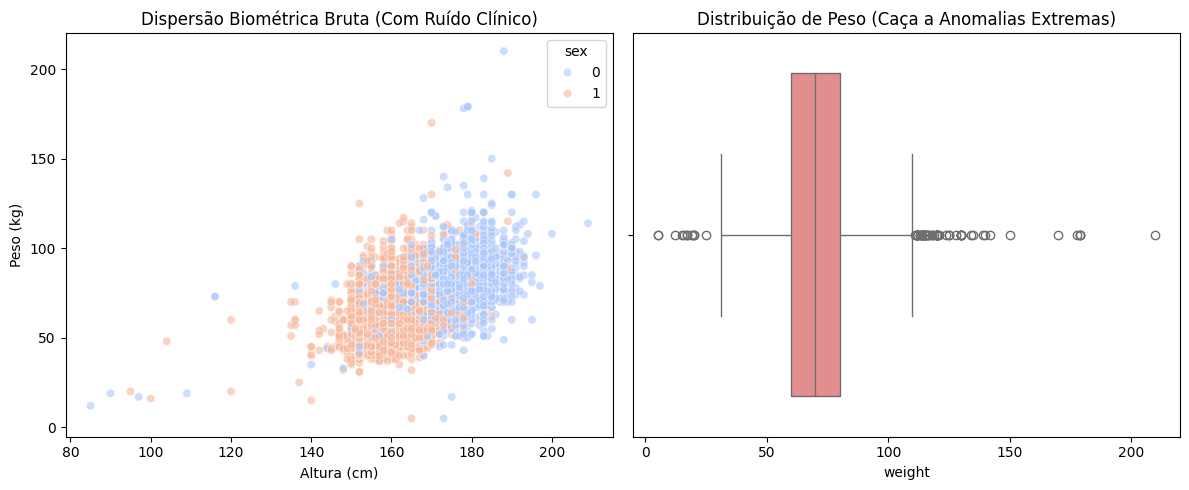

In [20]:
print(f"Dimensão da Matriz Analítica antes do Filtro Morfológico: {df_analytic.shape}")

# VISUALIZAÇÃO DE DENSIDADE (Pré-Filtro)
plt.figure(figsize=(12, 5))

# Gráfico A: Dispersão Multivariada (Anatomia)
plt.subplot(1, 2, 1)
# IMPORTANTE: O Seaborn nas versões mais novas prefere x/y/hue definidos claramente.
sns.scatterplot(data=df_analytic, x='height', y='weight', hue='sex', palette='coolwarm', alpha=0.6)
plt.title("Dispersão Biométrica Bruta (Com Ruído Clínico)")
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")

# Gráfico B: Identificação de Valores Extremos (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_analytic, x='weight', color='lightcoral')
plt.title("Distribuição de Peso (Caça a Anomalias Extremas)")

plt.tight_layout()
plt.show()

#### Visualizando as Anomalias em DataFrames


In [21]:
print("=== PACIENTES PEDIÁTRICOS ===")
df_criancas = df_analytic.query("age < 18").sort_values(by="age")
print(f"Total de menores de idade encontrados: {len(df_criancas)}")
# Mostrando os 5 mais novos para vermos se a proporção idade/peso/altura faz sentido
display(df_criancas[['ecg_id', 'age', 'sex', 'height', 'weight']].head(5))


print("\n=== ERROS DE DIGITAÇÃO DE PESO - Abaixo de 40kg ===")
# Aqui queremos ver quem pesa menos de 40kg.
# Se a pessoa tiver 40 anos e pesar 10kg, é a prova do erro do hospital em 1990.
df_peso_baixo = df_analytic.query("weight < 40").sort_values(by="weight")
print(f"Total de registros com peso sub-fisiológico: {len(df_peso_baixo)}")
display(df_peso_baixo[['ecg_id', 'age', 'sex', 'height', 'weight']].head(5))


print("\n=== ERROS DE DIGITAÇÃO DE ALTURA - Anões ou Gigantes ===")
# Alturas menores que 1.0m (140cm) ou maiores que 2.00m (200cm) em adultos
df_altura_bizarra = df_analytic.query("(height < 140 or height > 200) and age >= 18").sort_values(by="height")
print(f"Total de adultos com alturas anatomicamente improváveis: {len(df_altura_bizarra)}")
display(df_altura_bizarra[['ecg_id', 'age', 'sex', 'height', 'weight']].head(5))

=== PACIENTES PEDIÁTRICOS ===
Total de menores de idade encontrados: 42


,ecg_id,age,sex,height,weight
10262,10289,2,0,85,12
9712,9736,3,1,100,16
13634,13666,4,1,140,15
14226,14263,4,1,95,20
13908,13945,5,0,97,17



=== ERROS DE DIGITAÇÃO DE PESO - Abaixo de 40kg ===
Total de registros com peso sub-fisiológico: 41


,ecg_id,age,sex,height,weight
7921,7945,77,1,165,5
6038,6059,63,0,173,5
10262,10289,2,0,85,12
13634,13666,4,1,140,15
9712,9736,3,1,100,16



=== ERROS DE DIGITAÇÃO DE ALTURA - Anões ou Gigantes ===
Total de adultos com alturas anatomicamente improváveis: 13


,ecg_id,age,sex,height,weight
2529,2544,77,1,104,48
2681,2696,75,0,116,73
3135,3150,75,0,116,73
4019,4039,78,1,120,60
1580,1593,32,1,135,57


#### Execução do Filtro Morfológico e Demográfico

In [22]:
# Aplicando a "guilhotina" biológica com as restrições atualizadas (140cm a 200cm)
df_analytic = df_analytic[
    (df_analytic['age'] >= 18) &
    (df_analytic['height'] >= 140) & (df_analytic['height'] <= 200) &
    (df_analytic['weight'] >= 40)  & (df_analytic['weight'] <= 200)
].copy()

print(f"[LOG] Limpeza concluída. Dimensão final da Matriz Analítica: {df_analytic.shape}")

[LOG] Limpeza concluída. Dimensão final da Matriz Analítica: (6665, 10)


#### Análise do Target "scp_codes" - Abordagem Tabular



In [23]:
print("\n=== DISTRIBUIÇÃO DAS CLASSES DE DIAGNÓSTICO - DATAFRAME ===")

# Extração técnica: O scp_codes é um dicionário (ex: {'NORM': 100.0, 'SR': 0.0}).
# Vamos extrair todas as chaves (diagnósticos) para contar a frequência de cada doença.
lista_diagnosticos = []
for dicionario in df_analytic['scp_codes']:
    lista_diagnosticos.extend(list(dicionario.keys()))

# Conversão da contagem matemática para um DataFrame estruturado
contagem = Counter(lista_diagnosticos)
df_target = pd.DataFrame.from_dict(contagem, orient='index', columns=['Frequencia']).reset_index()
df_target.columns = ['Codigo_Diagnostico', 'Frequencia_Absoluta']

# Criando métricas relativas (Porcentagem) para análise da severidade de desbalanceamento
total_diagnosticos = df_target['Frequencia_Absoluta'].sum()
df_target['Representatividade (%)'] = ((df_target['Frequencia_Absoluta'] / total_diagnosticos) * 100).round(2)

# Ordenando do diagnóstico mais comum para o mais raro
df_target = df_target.sort_values(by='Frequencia_Absoluta', ascending=False).reset_index(drop=True)

print(f"Total de diagnósticos SCP únicos no escopo validado: {len(df_target)}")
display(df_target.head(15)) # Exibindo a matriz das 15 classes majoritárias


=== DISTRIBUIÇÃO DAS CLASSES DE DIAGNÓSTICO - DATAFRAME ===
Total de diagnósticos SCP únicos no escopo validado: 68


,Codigo_Diagnostico,Frequencia_Absoluta,Representatividade (%)
0,SR,5405,26.48
1,NORM,3099,15.18
2,STD_,910,4.46
3,LVH,822,4.03
4,NDT,712,3.49
5,ASMI,650,3.18
6,IMI,594,2.91
7,LAFB,582,2.85
8,VCLVH,472,2.31
9,ISC_,464,2.27


#### Análise do Target "scp_codes" - Abordagem Visual


=== HISTOGRAMA DE FREQUÊNCIA - TOP 15 CLASSES BRUTAS ===


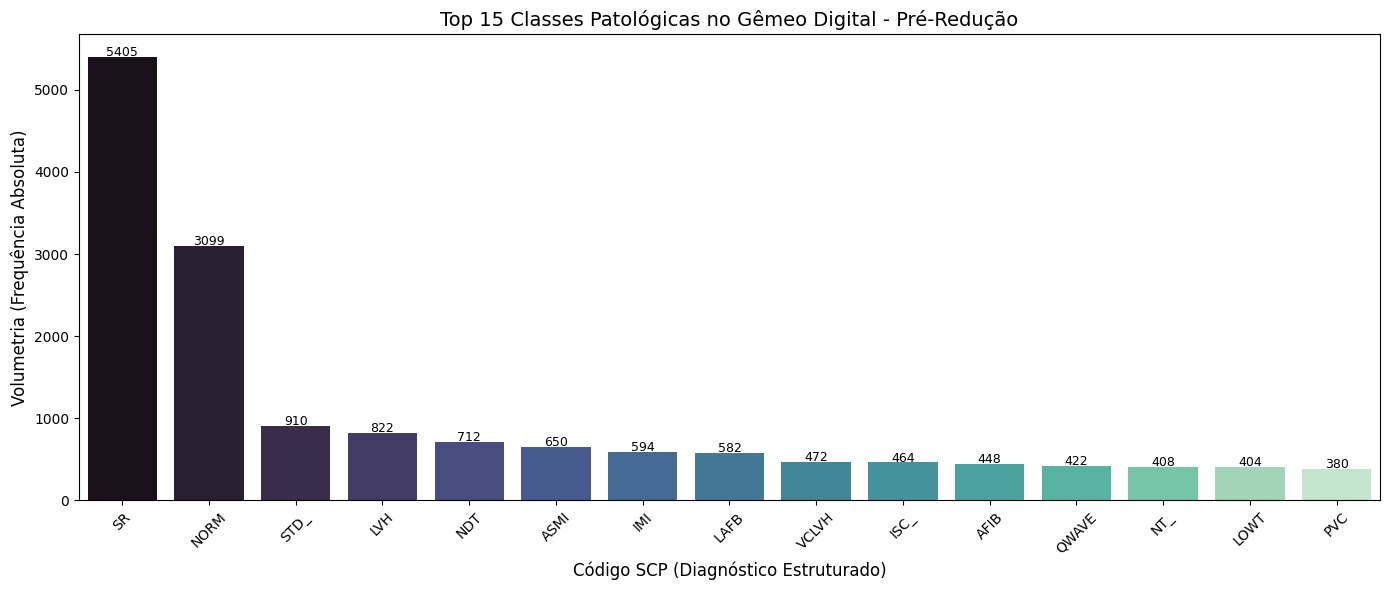

In [24]:
print("\n=== HISTOGRAMA DE FREQUÊNCIA - TOP 15 CLASSES BRUTAS ===")

plt.figure(figsize=(14, 6))

# Isolamento do Top 15 para manter a legibilidade visual e focar na cauda principal da distribuição.
# ARQUITETURA: Este plot evidencia o forte desbalanceamento natural da medicina (muitos exames Normais/SR 
# frente a patologias severas raras), validando a necessidade futura de métricas como o Macro-AUROC.
top_15_target = df_target.head(15)

# Plotagem otimizada: Atribuição explícita de 'hue' e 'legend=False' para garantir 
# a compatibilidade futura (Forward Compatibility) e suprimir warnings do ecossistema Seaborn.
sns.barplot(data=top_15_target, x='Codigo_Diagnostico', y='Frequencia_Absoluta', 
            hue='Codigo_Diagnostico', palette='mako', legend=False)

# Nomenclatura técnica de nível de produção
plt.title("Top 15 Classes Patológicas no Gêmeo Digital - Pré-Redução", fontsize=14)
plt.xlabel("Código SCP (Diagnóstico Estruturado)", fontsize=12)
plt.ylabel("Volumetria (Frequência Absoluta)", fontsize=12)
plt.xticks(rotation=45)

# Overlay quantitativo: Adição dos valores absolutos no topo das barras 
# para dispensar a inferência visual do leitor e facilitar a extração de métricas.
for index, row in top_15_target.iterrows():
    plt.text(index, row['Frequencia_Absoluta'] + 10, f"{row['Frequencia_Absoluta']}", color='black', ha="center", fontsize=9)

plt.tight_layout()
plt.show()

#### Redução de Dimensionalidade do Target - Superclasses

In [25]:
print("=== MAPEAMENTO DE SUPERCLASSES ===")

# Carregando o Dicionário Oficial de Doenças (Fornecido pelos autores do PTB-XL)
# O nome padrão do arquivo no PhysioNet é 'scp_statements.csv'
DISEASE_DICT_PATH = PTB_DIR / "scp_statements.csv"
scp_df = pd.read_csv(DISEASE_DICT_PATH, index_col=0)

# Isolando apenas os diagnósticos principais que pertencem a alguma Superclasse
# (Descartamos coisas como 'SR' que são apenas ritmo, focando na doença real)
scp_df = scp_df[scp_df.diagnostic == 1]

# Criando a Função de Tradução com Threshold de Confiança
def agregar_superclasses(dicionario_paciente):
    superclasses_encontradas = set() 
    
    # Itera sobre o código da doença e a certeza do médico (0.0 a 100.0)
    for codigo_doenca, probabilidade in dicionario_paciente.items():
        if codigo_doenca in scp_df.index:
            superclasse = scp_df.loc[codigo_doenca, 'diagnostic_class']
            
            # Threshold Clínico: Evento Confirmado (>= 50%)
            if probabilidade >= 50.0:
                superclasses_encontradas.add(superclasse)
            
            # Granularidade Avançada: Classe de Diagnóstico Suspeito (20% a 49.9%)
            elif 20.0 <= probabilidade < 50.0:
                superclasses_encontradas.add(superclasse + "_SUSPEITO")
                
    if not superclasses_encontradas:
        return ['Desconhecido']
    return list(superclasses_encontradas)

# plicando a tradução ao nosso Gêmeo Digital
df_analytic['superclasses'] = df_analytic['scp_codes'].apply(agregar_superclasses)

print(f"Total de Gêmeos Digitais retidos: {len(df_analytic)}")
print("\nVisão da transformação - Incertezas tratadas e mapeadas:")
display(df_analytic[['ecg_id', 'scp_codes', 'superclasses']].head(10))

=== MAPEAMENTO DE SUPERCLASSES ===
Total de Gêmeos Digitais retidos: 6665

Visão da transformação - Incertezas tratadas e mapeadas:


,ecg_id,scp_codes,superclasses
100,101,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
115,116,"{'NDT': 100.0, 'SR': 0.0}",[STTC]
135,136,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
138,146,"{'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, '...","[MI_SUSPEITO, STTC, HYP]"
148,156,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
184,192,"{'IRBBB': 100.0, 'SR': 0.0}",[CD]
245,253,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
247,255,"{'IRBBB': 100.0, 'PVC': 100.0, 'SR': 0.0}",[CD]
248,256,"{'CLBBB': 100.0, 'PVC': 100.0, 'SR': 0.0}",[CD]
249,257,"{'ASMI': 50.0, 'IMI': 100.0, 'PAC': 0.0, 'LOWT...",[MI]


#### Distribuição das Superclasses - DataFrame

In [26]:
print("=== DISTRIBUIÇÃO DE SUPERCLASSES ===")

# Extraindo todas as superclasses das listas dos pacientes
todas_superclasses = []
for lista_classes in df_analytic['superclasses']:
    todas_superclasses.extend(lista_classes)

# Contagem e criação do DataFrame
contagem_super = Counter(todas_superclasses)
df_super = pd.DataFrame.from_dict(contagem_super, orient='index', columns=['Frequencia_Absoluta']).reset_index()
df_super.columns = ['Superclasse', 'Frequencia_Absoluta']

# Calculando a Representatividade (%)
total_super = df_super['Frequencia_Absoluta'].sum()
df_super['Representatividade (%)'] = ((df_super['Frequencia_Absoluta'] / total_super) * 100).round(2)

# Ordenando do maior para o menor
df_super = df_super.sort_values(by='Frequencia_Absoluta', ascending=False).reset_index(drop=True)

display(df_super)

=== DISTRIBUIÇÃO DE SUPERCLASSES ===


,Superclasse,Frequencia_Absoluta,Representatividade (%)
0,NORM,3086,36.24
1,STTC,1699,19.95
2,CD,1494,17.55
3,MI,1010,11.86
4,HYP,784,9.21
5,Desconhecido,214,2.51
6,HYP_SUSPEITO,165,1.94
7,MI_SUSPEITO,45,0.53
8,NORM_SUSPEITO,8,0.09
9,STTC_SUSPEITO,8,0.09


#### Distribuição das Superclasses - Visualizações


=== RENDERIZAÇÃO: DISTRIBUIÇÃO DAS SUPERCLASSE ===


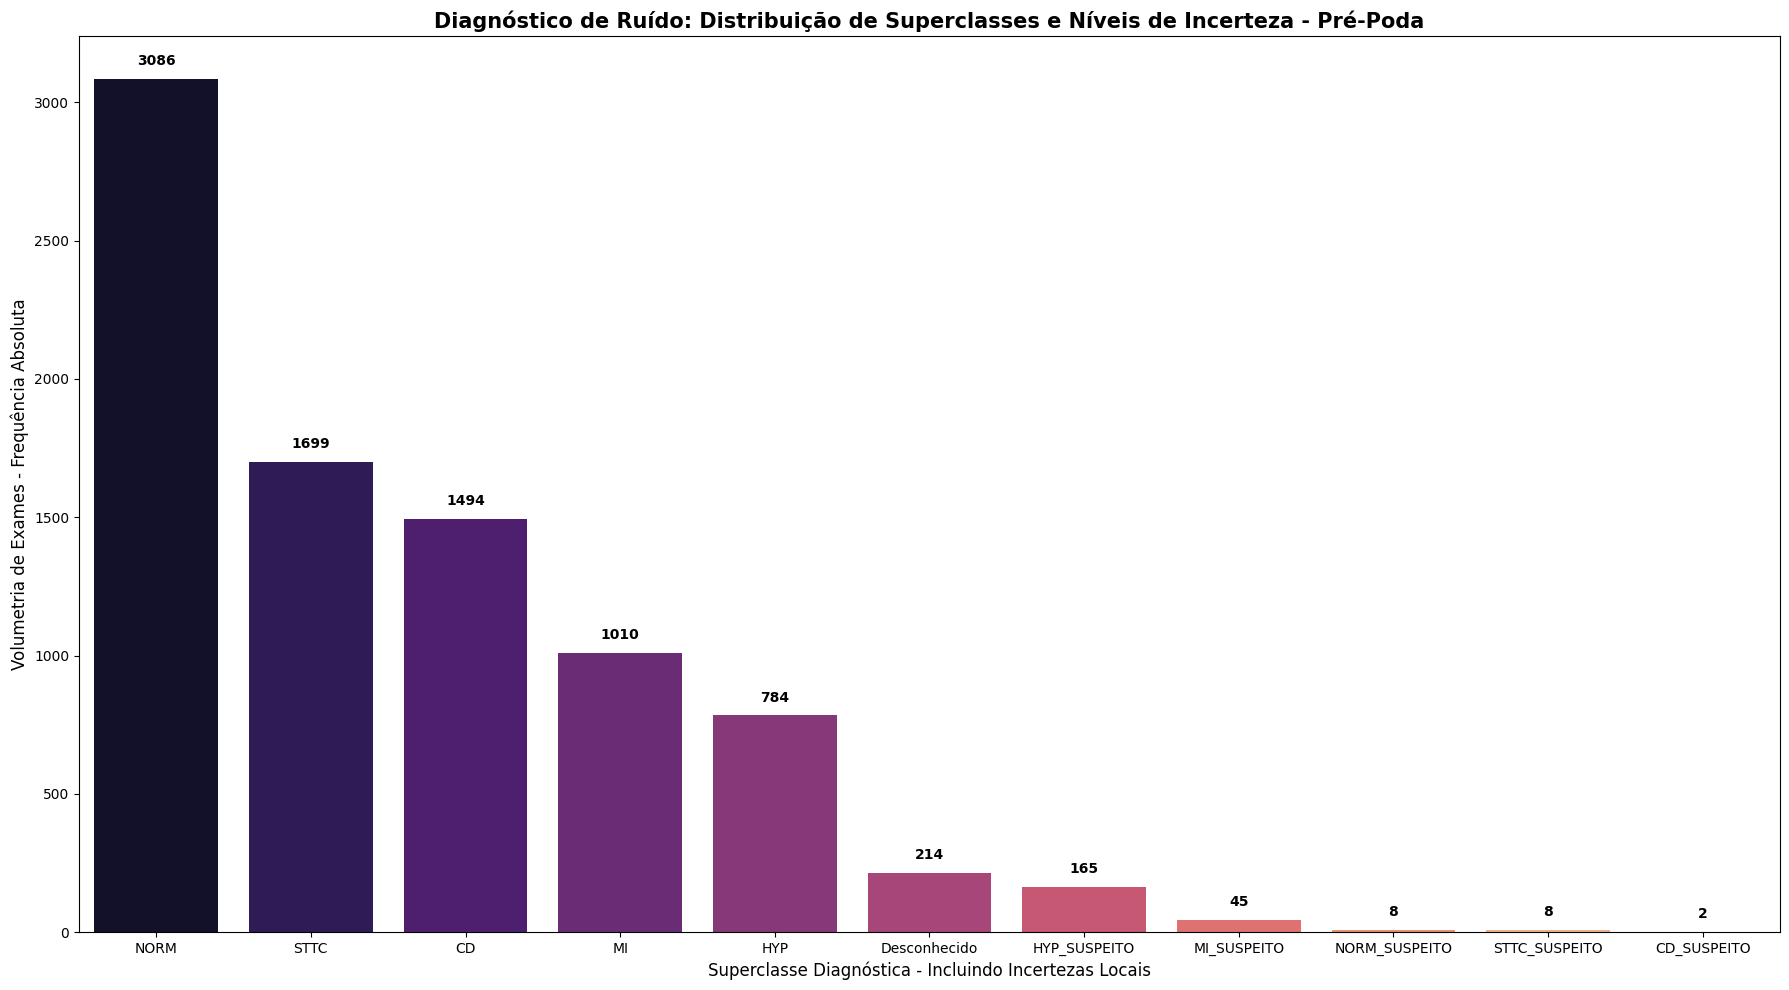


[LOG] Análise do espaço de classes brutas concluída.
[LOG] A fragmentação por incerteza clínica está visualmente mapeada. Avançando para a Poda Seletiva.


In [27]:
print("\n=== RENDERIZAÇÃO: DISTRIBUIÇÃO DAS SUPERCLASSE ===")

plt.figure(figsize=(18, 10))

# Plotagem otimizada (Supressão de warnings do Seaborn via atribuição de 'hue' explícito)
# ARQUITETURA DE DECISÃO: Este gráfico é vital pois escancara a pulverização da incerteza médica.
# Observe a presença das classes de baixa confiança (sujeitas ao sufixo '_SUSPEITO') e 'Desconhecido'. 
# A visualização desse "ruído estatístico" é o que justifica matematicamente a necessidade 
# da nossa próxima etapa no pipeline: a Poda Seletiva e a criação da 6ª Classe de Triagem (INCONCLUSIVO).
sns.barplot(data=df_super, x='Superclasse', y='Frequencia_Absoluta', 
            hue='Superclasse', palette='magma', legend=False)

# Nomenclatura ajustada para refletir o estado exato do pipeline (11 classes brutas espalhadas, não 5)
plt.title("Diagnóstico de Ruído: Distribuição de Superclasses e Níveis de Incerteza - Pré-Poda", fontsize=15, fontweight='bold')
plt.xlabel("Superclasse Diagnóstica - Incluindo Incertezas Locais", fontsize=12)
plt.ylabel("Volumetria de Exames - Frequência Absoluta", fontsize=12)

# Overlay quantitativo para relatórios de auditoria de dados
for index, row in df_super.iterrows():
    plt.text(index, row['Frequencia_Absoluta'] + 50, f"{row['Frequencia_Absoluta']}", color='black', ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[LOG] Análise do espaço de classes brutas concluída.")
print("[LOG] A fragmentação por incerteza clínica está visualmente mapeada. Avançando para a Poda Seletiva.")

### Avaliação da Classe "Desconhecido" e do Limiar de Incerteza

A aplicação do *Threshold* Clínico (P(Diagnóstico) >= 50%) produziu o efeito estatístico rigoroso previsto em nossa modelagem: a ramificação do vetor alvo em subcategorias de incerteza (ex., `MI_SUSPEITO`) e a alocação inicial de 214 instâncias na classe de exames estritamente dúbios (`['Desconhecido']`).

Ao invés de procedermos com a supressão sumária (exclusão cega) destes registros do *dataset* — uma prática comum em laboratório, mas perigosa na clínica —, é imperativo aplicar os preceitos de *Data Quality Assurance* (DQA). Torna-se necessário auditar estes pacientes órfãos de diagnóstico para validar a seguinte premissa estrutural: 

**Estes registros contêm falsos negativos de patologias isquêmicas severas devido à rigidez excessiva do nosso limiar, ou o algoritmo atuou conforme o esperado, isolando laudos de genuína baixa confiança e artefatos de captação para compor a nossa futura 6ª classe de triagem preditiva (`INCONCLUSIVO`)?**

In [28]:
# AUDITORIA TABULAR: PACIENTES COM DIAGNÓSTICO INCERTO OU DESCONHECIDO
print("=== INICIANDO RASTREAMENTO DE INCERTEZA DIAGNÓSTICA ===")

# Isolamento das instâncias classificadas como 'Desconhecido' OU contendo o sufixo '_SUSPEITO'
# ARQUITETURA: Usamos uma função lambda vetorizada para atuar como um "scanner" nas listas de cada paciente.
# O objetivo é separar temporariamente os exames dúbios para provar matematicamente que a incerteza 
# gerada pelo Threshold (>= 50%) reflete a hesitação médica real, e não um erro de parsing.
mask_incerteza = df_analytic['superclasses'].apply(lambda x: any('Desconhecido' in cls or 'SUSPEITO' in cls for cls in x))
df_incertos = df_analytic[mask_incerteza].copy()

print(f"[LOG] Total de instâncias retidas para auditoria - Suspeitos + Desconhecidos: {len(df_incertos)}")

# Extração e planificação dos códigos originais (scp_codes) que acionaram o alerta de incerteza
codigos_orfaos = []
for dicionario in df_incertos['scp_codes']:
    codigos_orfaos.extend(list(dicionario.keys()))

# Consolidação e ordenação estatística das frequências
contagem_orfaos = Counter(codigos_orfaos)
df_orfaos = pd.DataFrame.from_dict(contagem_orfaos, orient='index', columns=['Frequencia_no_Ruido']).reset_index()
df_orfaos.columns = ['Codigo_Original_Nao_Mapeado', 'Frequencia_no_Ruido']
df_orfaos = df_orfaos.sort_values(by='Frequencia_no_Ruido', ascending=False).reset_index(drop=True)

# RENDERIZAÇÃO VISUAL: HEATMAP E FORMATAÇÃO DE LAUDOS
print("\nDistribuição de Frequência dos Códigos Originais Rejeitados/Suspeitos:")

# Aplicação de Gradient Mapping (Heatmap) na coluna de frequência
# O colormap 'OrRd' (Orange-Red) destaca visualmente as patologias que mais causam divergência médica.
styled_df_orfaos = df_orfaos.head(15).style.background_gradient(
    cmap='OrRd', 
    subset=['Frequencia_no_Ruido']
).set_caption("Top 15 Códigos SCP com Alta Incerteza Clínica - Heatmap")

display(styled_df_orfaos)


print("\nAmostragem Textual - Reporte Original vs Codificação SCP vs Superclasse Atribuída:")

# Join com o dataframe original bruto (df) para recuperação do laudo (report) em texto livre
df_incertos_com_texto = df_incertos.merge(df[['ecg_id', 'report']], on='ecg_id', how='left')

# Aplicação de Text-Wrapping para evitar truncamento de strings longas e permitir auditoria clínica plena (NLP)
styled_text_df = df_incertos_com_texto[['ecg_id', 'age', 'scp_codes', 'superclasses', 'report']].head(10).style.set_properties(
    subset=['report', 'scp_codes', 'superclasses'], 
    **{'text-align': 'left', 'white-space': 'pre-wrap'}
).set_caption("Amostra Bruta para Validação Cruzada do NLP Médico")

display(styled_text_df)

=== INICIANDO RASTREAMENTO DE INCERTEZA DIAGNÓSTICA ===
[LOG] Total de instâncias retidas para auditoria - Suspeitos + Desconhecidos: 437

Distribuição de Frequência dos Códigos Originais Rejeitados/Suspeitos:


,Codigo_Original_Nao_Mapeado,Frequencia_no_Ruido
0,SR,312
1,LVH,195
2,VCLVH,170
3,IMI,96
4,STD_,72
5,ASMI,70
6,QWAVE,43
7,PACE,38
8,ISC_,30
9,AFIB,29



Amostragem Textual - Reporte Original vs Codificação SCP vs Superclasse Atribuída:


,ecg_id,age,scp_codes,superclasses,report
0,146,45,"{'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, 'SR': 0.0}","['MI_SUSPEITO', 'STTC', 'HYP']",sinusrytm ospecifikt skÄnkelblock avvikande qrs(t) fÖrlopp inferior infarkt Ålder ej bestÄmmbar
1,311,47,{'AMI': 15.0},['Desconhecido'],trace only requested.
2,319,85,"{'ASMI': 35.0, 'NT_': 0.0, 'QWAVE': 0.0, 'SR': 0.0}",['MI_SUSPEITO'],sinus rhythm. possible left atrial enlargement. q wave and small r wave in v2 suggesting old anteroseptal myocardial infarction. non-specific t wave flattening in v6.
3,323,73,"{'IMI': 35.0, 'QWAVE': 0.0, 'SR': 0.0}",['MI_SUSPEITO'],"sinus rhythm. q waves in ii, iii, avf suggesting old inferior myocardial infarction."
4,333,72,"{'LVH': 35.0, 'STD_': 0.0, 'VCLVH': 0.0, 'SR': 0.0}",['HYP_SUSPEITO'],"sinus rhythm. voltages are high in chest leads suggesting lvh. non-specific st segment depression in i, ii, v4,5,6. Edit: LVH 35, VH 10,7, Sokolow 3,3, wahrscheinlich normal"
5,351,89,"{'AFIB': 100.0, 'NST_': 0.0}",['Desconhecido'],atrial fibrillation with rapid ventricular response. non-specific st-t wave changes.
6,407,51,"{'IMI': 15.0, 'LVOLT': 0.0, 'SR': 0.0}",['Desconhecido'],sinus rhythm. low limb lead voltage. no definite pathology.
7,430,62,"{'ASMI': 15.0, 'SR': 0.0}",['Desconhecido'],sinus rhythm. qs complexes in v2 suggesting old anteroseptal infarct. otherwise normal ecg.
8,442,80,"{'IMI': 15.0, 'LVOLT': 0.0, 'SR': 0.0}",['Desconhecido'],sinus rhythm. low limb lead voltage. possible old inferior myocardial infarction.
9,617,54,"{'ASMI': 15.0, 'SR': 0.0}",['Desconhecido'],"sinus rhythm. tiny r wave in v2, this may be normal but old anteroseptal myocardial infarction cannot be excluded. no definite ecg evidence to suggest pulmonary embolism."


### Validação Cruzada via Processamento de Linguagem Natural (NLP)

A análise tabular (abrangendo 437 instâncias) certifica a altíssima eficácia do filtro de confiança (*Threshold*). Ao cruzar os rótulos numéricos de probabilidade **_(scp_codes)_** com os laudos médicos literais escritos no momento do exame **_(report)_**, atestamos os seguintes comportamentos fundamentais:

1. **Correlação Léxica de Incerteza (Probabilidades <= 35%):** No agrupamento das classes **__SUSPEITO_** e **_Desconhecido_**, os marcadores de isquemia **_(IMI, ASMI)_** e hipertrofia **_(LVH)_** apresentam probabilidades atenuadas. A leitura do texto livre confirma a hesitação do cardiologista plantonista:
   * *Paciente 311:* Probabilidade de AMI em 15.0%. Laudo: *"trace only requested"* (Inconclusivo).
   * *Paciente 442:* Probabilidade de IMI em 15.0%. Laudo: *"possible old inferior myocardial infarction"* (Incerto).
   * *Paciente 617:* Probabilidade de ASMI em 15.0%. Laudo: *"infarction cannot be excluded"* (Hipótese não descartada, mas não confirmada).

2. **O Risco do *Shortcut Learning* **_(PACE)_:**** A tabela de calor evidenciou a retenção de pacientes dependentes de Marca-passos **_(PACE)._** Em arquiteturas convolucionais (CNNs) aplicadas a Séries Temporais Eletrocardiográficas, artefatos contínuos de dispositivos implantáveis induzem ao *Shortcut Learning* (Aprendizado por Atalho). O otimizador prioriza os picos de voltagem da bateria do dispositivo, inviabilizando a abstração da morfologia real do miocárdio humano.


3. **Casos Clínicos Híbridos (A Preservação de Diagnósticos):** Observamos o Paciente 146. A sua classe **_IMI_** foi taxada em 35.0% (tornando-se **_MI_SUSPEITO_**), contudo, as suas isquemias e hipertrofias associadas possuíam altíssima confiança, retendo os rótulos puros **_STTC_** e **_HYP._**


**Diretriz Arquitetural de MLOps:** O algoritmo atuou perfeitamente ao não forçar patologias duvidosas como se fossem certezas absolutas. Contudo, a supressão sumária em formato "guilhotina" (Drop Row) não apenas apagaria injustamente os exames híbridos (como o Paciente 146), como também destruiria o valioso registro dessa hesitação médica (os 214 casos estritamente isolados). 

Para otimizar a pureza preditiva e manter a segurança clínica, executaremos o protocolo de **Poda Seletiva e Gestão de Incerteza**: exames híbridos terão seus rótulos fracos podados (mantendo apenas o *Ground Truth* forte), enquanto os exames estritamente dúbios não serão deletados, mas envelopados na nossa 6ª classe de segurança abstencionista **(INCONCLUSIVO).**

In [29]:
print("=== INICIANDO PROTOCOLO DE PODA SELETIVA DE RÓTULOS ===")
tamanho_inicial = len(df_analytic)

# Função de Poda: Itera sobre o array de classes.
# Objetivo: Reter o Ground Truth de alta confiança e mapear a dúvida para a classe de Triagem.
def purgar_incerteza(lista_classes):
    classes_puras = [cls for cls in lista_classes if 'SUSPEITO' not in cls and 'Desconhecido' not in cls]
    
    # Se restou alguma classe clinicamente confirmada, a mantemos.
    if len(classes_puras) > 0:
        return classes_puras
    # Se todas eram incertas, acionamos a classe de abstencionismo preditivo (A 6ª Classe).
    else:
        return ['INCONCLUSIVO']

# Aplicação da função de transformação no vetor alvo do Gêmeo Digital
df_analytic['superclasses'] = df_analytic['superclasses'].apply(purgar_incerteza)

# Expurgo de Instâncias Órfãs: Validação de Segurança (Sanity Check)
# Como mapeamos as incertezas para 'INCONCLUSIVO', não devem existir arrays vazios.
df_analytic = df_analytic[df_analytic['superclasses'].map(len) > 0].copy()

tamanho_final = len(df_analytic)
pacientes_removidos = tamanho_inicial - tamanho_final

print(f"[LOG] Protocolo de poda seletiva e gestão de incerteza executado com sucesso.")
print(f"[LOG] Instâncias descartadas cegamente: {pacientes_removidos} (Casos dúbios preservados como 'INCONCLUSIVO').")
print(f"[LOG] Dimensão atualizada e purificada da Matriz Analítica: {df_analytic.shape}")

# RECALCULO DA DISTRIBUIÇÃO ESTATÍSTICA (AGORA INCLUINDO A CLASSE DE TRIAGEM)
todas_superclasses_puras = []
for lista_classes in df_analytic['superclasses']:
    todas_superclasses_puras.extend(lista_classes)

contagem_super_pura = Counter(todas_superclasses_puras)
df_super_final = pd.DataFrame.from_dict(contagem_super_pura, orient='index', columns=['Frequencia_Absoluta']).reset_index()
df_super_final.columns = ['Superclasse', 'Frequencia_Absoluta']

# Ordenação para a plotagem
df_super_final = df_super_final.sort_values(by='Frequencia_Absoluta', ascending=False).reset_index(drop=True)

=== INICIANDO PROTOCOLO DE PODA SELETIVA DE RÓTULOS ===
[LOG] Protocolo de poda seletiva e gestão de incerteza executado com sucesso.
[LOG] Instâncias descartadas cegamente: 0 (Casos dúbios preservados como 'INCONCLUSIVO').
[LOG] Dimensão atualizada e purificada da Matriz Analítica: (6665, 11)


#### Remoção de Ruído Final

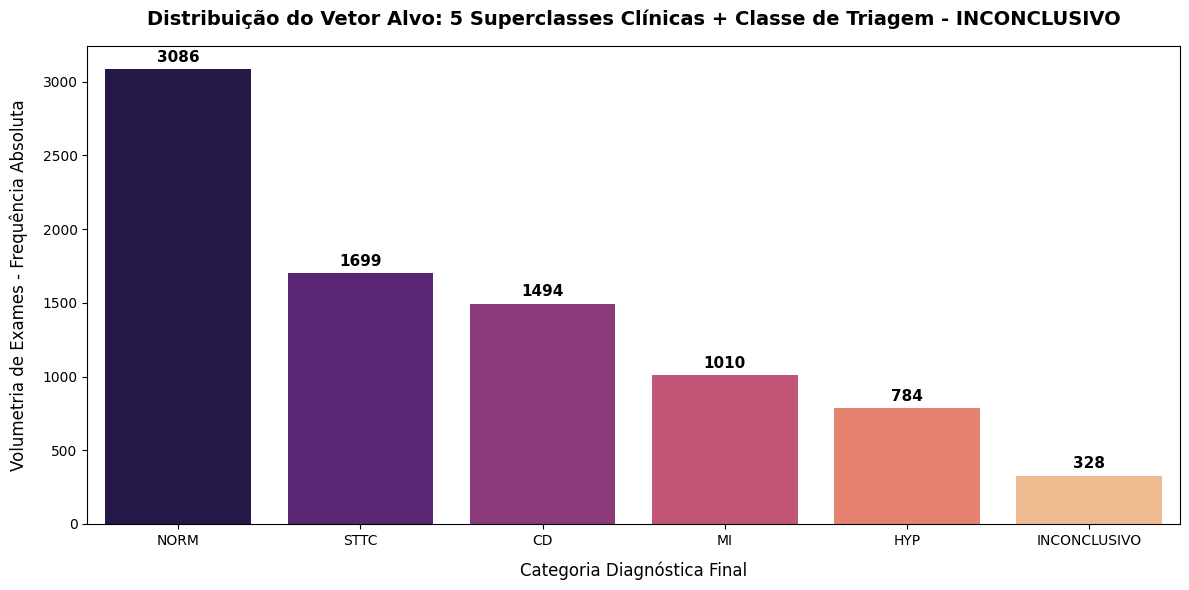


[LOG] Higienização do vetor alvo concluída. Subclasses minoritárias consolidadas.
[LOG] O ecossistema está apto para transição à etapa de Feature Engineering.


In [30]:
# PLOTAGEM DO VETOR ALVO (GROUND TRUTH + CLASSE DE TRIAGEM)
plt.figure(figsize=(12, 6))

# A paleta Magma aplicada com 'hue' para suprimir warnings
sns.barplot(data=df_super_final, x='Superclasse', y='Frequencia_Absoluta', 
            hue='Superclasse', palette='magma', legend=False)

# Títulos ajustados refletindo a nova arquitetura de MLOps
plt.title("Distribuição do Vetor Alvo: 5 Superclasses Clínicas + Classe de Triagem - INCONCLUSIVO", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoria Diagnóstica Final", fontsize=12, labelpad=10)
plt.ylabel("Volumetria de Exames - Frequência Absoluta", fontsize=12, labelpad=10)

# Rotulação dos valores exatos sobre as barras
for index, row in df_super_final.iterrows():
    plt.text(index, row['Frequencia_Absoluta'] + 50, f"{row['Frequencia_Absoluta']}", color='black', ha="center", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n[LOG] Higienização do vetor alvo concluída. Subclasses minoritárias consolidadas.")
print("[LOG] O ecossistema está apto para transição à etapa de Feature Engineering.")

### Matemática da Qualidade vs Quantidade: O Impacto do Feature Engineering

À primeira vista, alocar quase $70\%$ do dataset no *Gateway de Triagem* (mantendo apenas pacientes com Altura e Peso no modelo primário) parece uma decisão limitante para um modelo de Deep Learning. No entanto, a matemática da **Densidade de Informação** prova o contrário.

Vamos comparar os dois cenários através do tamanho final das matrizes (Shape) e do volume total de dados gerados:

<br>

**Cenário A: Foco em Quantidade (Abordagem Larga)**
Nesta abordagem cega, preservaríamos todas as linhas, mas seríamos obrigados a deletar colunas biológicas essenciais (Peso/Altura) devido à alta taxa de valores nulos.
- **Linhas (Pacientes):** $21.799$
- **Colunas Base:** $7$ **(ecg_id, patient_id, age, sex, strat_fold, filename_lr, scp_codes)**
- **Feature Engineering Possível:** Muito limitado. Com apenas **_age_** e **_sex_**, a riqueza de contexto biológico inexiste.
- **Shape Final Estimado:** $(21.799, 8)$
- **Volume Total de Células de Dados:** $21.799 \times 8 = 174.392$ pontos de dados.

<br>

**Cenário B: Foco em Qualidade (A Arquitetura Dual de Engineered Features)**
Aqui, aceitamos a redução de linhas no núcleo principal para manter a integridade fisiológica, o que abre portas para um Feature Engineering agressivo e controle de vieses.
- **Linhas (Pacientes Principais):** $6.665$
- **Colunas Base:** $10$ (As 7 anteriores + **_height_** + **_weight_** + **_idade_anonimizada_hipaa_**)
- **Feature Engineering Possível:** Alto. A partir destas bases, podemos derivar biologia sólida: **IMC, Categoria_IMC, BSA (Área de Superfície Corporal), LBM (Massa Magra), TMB (Metabolismo Basal) e Risco_Idade_IMC.**
- **Shape Final Estimado:** $(6.665, 22)$
- **Volume Total de Células de Dados:** $6.665 \times 22 = 146.630$ pontos de dados hiper-densos.
- **Densidade Fisiológica:** 22 dimensões fornecem um contexto clínico para análise multivariada profunda, compensando amplamente o menor número de linhas.

**Resumo de Engenharia:**
- Nós descartamos **colunas (features)** que representam ruído técnico de hardware, sinais artificiais (marcapassos) ou dados esparsos demais para utilidade estatística. Contudo, nós não descartamos os **pacientes (linhas)** difíceis; a complexidade de seus exames é o que treina nossa 6ª classe de triagem **(INCONCLUSIVO).**

#### Feature Engineering - Expansão do Espaço de Características

In [31]:
print(f"=== Dimensão Inicial do Dataset Analítico - Base: {df_analytic.shape} ===")

# ==============================================================================
# FEATURES 1 a 4: GEOMETRIA CORPORAL E RISCO COMPOSTO
# ==============================================================================

# === FEATURE 1: Índice de Massa Corporal (IMC) ===
# Transformação da estatura de centímetros para metros na equação: IMC = peso / (altura_m)^2
df_analytic["imc"] = df_analytic["weight"] / ((df_analytic["height"] / 100) ** 2)
df_analytic["imc"] = df_analytic["imc"].round(2)

# === FEATURE 2: Discretização do IMC (Feature Categórica Ordinal) ===
condicoes = [
    (df_analytic["imc"] < 18.5),
    (df_analytic["imc"] >= 18.5) & (df_analytic["imc"] < 25),
    (df_analytic["imc"] >= 25) & (df_analytic["imc"] < 30),
    (df_analytic["imc"] >= 30)
]
categorias = ["Baixo Peso", "Normal", "Sobrepeso", "Obesidade"]
df_analytic["imc_categoria"] = np.select(condicoes, categorias, default="Desconhecido")

# === FEATURE 3: Área de Superfície Corporal (BSA - Equação de Mosteller) ===
# ARQUITETURA: Essencial para IA Médica, pois o tamanho da superfície corporal 
# afeta diretamente a amplitude (voltagem) da onda de ECG captada nos eletrodos.
df_analytic["bsa"] = np.sqrt((df_analytic["height"] * df_analytic["weight"]) / 3600)
df_analytic["bsa"] = df_analytic["bsa"].round(3)

# === FEATURE 4: Termo de Interação (Risco Composto Idade x IMC) ===
df_analytic["risco_idade_imc"] = (df_analytic["age"] * df_analytic["imc"]).round(2)

print(f"\n[+] Extração do Bloco Geométrico (IMC, BSA) concluída. Nova dimensão: {df_analytic.shape}")
display(df_analytic[["ecg_id", "height", "weight", "imc", "imc_categoria", "bsa", "risco_idade_imc"]].head(3))

=== Dimensão Inicial do Dataset Analítico - Base: (6665, 11) ===

[+] Extração do Bloco Geométrico (IMC, BSA) concluída. Nova dimensão: (6665, 15)


,ecg_id,height,weight,imc,imc_categoria,bsa,risco_idade_imc
100,101,172,72,24.34,Normal,1.855,1168.32
115,116,174,74,24.44,Normal,1.891,1197.56
135,136,167,72,25.82,Sobrepeso,1.828,1342.64


`Feature Engineering: Expansão do Espaço de Características`

Com o terreno limpo e a incerteza mapeada, iniciamos a expansão da dimensionalidade. O objetivo aqui é converter dados estáticos (Idade, Peso, Altura) em **Modelos Metabólicos e Geométricos**.

` O Poder do Binning e Feature Cross`
Na Engenharia de Machine Learning, converter uma variável contínua em faixas é chamado de **Binning**. Cruzar duas variáveis para criar um grupo demográfico específico chama-se **Feature Cross**. 

**Por que isso é vital para Cardiologia Computacional?**
O risco cardíaco não cresce de forma perfeitamente linear; o corpo envelhece em "degraus". Um modelo de IA cru pode demorar centenas de épocas para entender a diferença metabólica entre 49 e 50 anos. No entanto, ao injetarmos a feature explícita "Paciente entrou no grupo de Risco de Meia-Idade", a rede neural aplica saltos de peso matemático imediatamente.

`Agregação de Risco (Mean Encoding com Prevenção de Leakage)`

Saber que um paciente possui IMC 28 (Sobrepeso) é útil. Mas calcular matematicamente que este IMC está *dois desvios-padrão acima da média do grupo demográfico exato daquele paciente* é o que chamamos de Risco Relativo. Isso aciona alertas vermelhos de altíssima precisão na Rede Convolucional.

**Feature 5 --> Feature 8 (Binning):**
- Faixa Etária.
    - (Criar os "baldes" de idade baseados nas diretrizes médicas de risco).

**Feature 6 --> Feature 9 (Feature Cross):**
- Coorte Demográfica.
    - (Juntar o Sexo com a Faixa Etária. Ex: Mulher_Meia_Idade).

**Feature 7 --> Feature 10 & 11 (Agregação):**
- Desvio de Risco do Grupo.
    - (Calcular a média do IMC/Peso daquela Coorte específica e medir o quanto o paciente atual está desviando do "normal" do grupo dele).

##### Fórmulas Biológicas

In [32]:
# ==============================================================================
# FEATURES 5 a 7: BIOLOGIA METABÓLICA (LBM, TBM E RISCO BASE)
# ==============================================================================

# Máscaras booleanas para isolamento de Sexo (0 = Masculino, 1 = Feminino)
mask_masc = df_analytic["sex"] == 0
mask_fem = df_analytic["sex"] == 1

# === FEATURE 5: LBM (Massa Corporal Magra - Equação de Boer) ===
df_analytic.loc[mask_masc, "lbm"] = (0.407 * df_analytic["weight"]) + (0.267 * df_analytic["height"]) - 19.2
df_analytic.loc[mask_fem, "lbm"] = (0.252 * df_analytic["weight"]) + (0.473 * df_analytic["height"]) - 48.3
df_analytic["lbm"] = df_analytic["lbm"].round(2)

# === FEATURE 6: TMB (Taxa de Metabolismo Basal - Equação de Mifflin-St Jeor) ===
# ARQUITETURA DE SEGURANÇA: Como esta equação é dependente da idade, a nossa flag anterior 
# ('idade_anonimizada_hipaa') salva o modelo aqui. O TMB de centenários será calculado
# com o teto de 89 anos, mas a Rede Neural utilizará a flag para compensar essa falha matemática.
df_analytic.loc[mask_masc, "tbm"] = (10 * df_analytic["weight"]) + (6.25 * df_analytic["height"]) - (5 * df_analytic["age"]) + 5
df_analytic.loc[mask_fem, "tbm"] = (10 * df_analytic["weight"]) + (6.25 * df_analytic["height"]) - (5 * df_analytic["age"]) - 161
df_analytic["tbm"] = df_analytic["tbm"].round(2)

# === FEATURE 7: Categoria de Risco Clínico Base (Idade x Sexo) ===
condicoes_risco = [
    (df_analytic["sex"] == 0) & (df_analytic["age"] < 45),
    (df_analytic["sex"] == 0) & (df_analytic["age"] >= 45),
    (df_analytic["sex"] == 1) & (df_analytic["age"] < 55),
    (df_analytic["sex"] == 1) & (df_analytic["age"] >= 55)
]
categorias_risco = ["Baixo (Homem)", "Alto (Homem)", "Baixo (Mulher)", "Alto (Mulher)"]
df_analytic["risco_base"] = np.select(condicoes_risco, categorias_risco, default="Desconhecido")

print(f"\n[+] Extração do Bloco Metabólico (LBM, TBM, Risco Base) concluída. Nova dimensão: {df_analytic.shape}")
display(df_analytic[["ecg_id", "sex", "age", "lbm", "tbm", "risco_base"]].head(3))


[+] Extração do Bloco Metabólico (LBM, TBM, Risco Base) concluída. Nova dimensão: (6665, 18)


,ecg_id,sex,age,lbm,tbm,risco_base
100,101,1,48,51.20,1394.00,Baixo (Mulher)
115,116,1,49,52.65,1421.50,Baixo (Mulher)
135,136,0,52,54.69,1508.75,Alto (Homem)


##### Agrupamentos Demográficos e Risco Relativo

In [33]:
# ==============================================================================
# FEATURES 8 a 10: COORTES DEMOGRÁFICAS E MEAN ENCODING (RISCO RELATIVO)
# ==============================================================================

# === FEATURE 8: Faixa Etária (Binning Fisiológico) ===
cortes_idade = [0, 30, 45, 60, 75, 100]
nomes_faixas = ["<30 (Jovem)", "30-44 (Adulto)", "45-59 (Meia-Idade)", "60-74 (Idoso)", ">75 (Ancião)"]

df_analytic["faixa_etaria"] = pd.cut(df_analytic["age"], bins=cortes_idade, labels=nomes_faixas, right=False)

# === FEATURE 9: Coorte Demográfica (Feature Cross: Sexo + Faixa Etária) ===
df_analytic["sexo_str"] = np.where(df_analytic["sex"] == 0, "M", "F")
df_analytic["coorte_demografica"] = df_analytic["sexo_str"] + "_" + df_analytic["faixa_etaria"].astype(str)
df_analytic = df_analytic.drop(columns=["sexo_str"]) # Limpando a coluna auxiliar da memória

# === FEATURE 10: Desvio Relativo ao Grupo (Agregação de Risco) ===
# 🚨 PREVENÇÃO DE DATA LEAKAGE (MUITO IMPORTANTE)
# Calculamos as médias populacionais utilizando EXCLUSIVAMENTE o conjunto de Treino (Folds 1 a 8).
# Isso impede o vazamento de informações e simula a cegueira do modelo perante dados futuros (Folds 9 e 10).

df_treino = df_analytic[df_analytic['strat_fold'] <= 8]

# Cria um dicionário estático com as médias aprendidas estritamente no Treino
dicionario_medias_imc = df_treino.groupby("coorte_demografica")["imc"].mean().round(2).to_dict()

# Mapeia as médias pré-calculadas para o dataset inteiro (Treino + Validação + Teste)
df_analytic["imc_medio_da_coorte"] = df_analytic["coorte_demografica"].map(dicionario_medias_imc)

# Fallback de Segurança: Se algum grupo raro só existir no Teste, preenchemos com a média global do treino
media_global_treino = df_treino["imc"].mean().round(2)
df_analytic["imc_medio_da_coorte"] = df_analytic["imc_medio_da_coorte"].fillna(media_global_treino)

# Calcula o desvio metabólico final (O quão "fora do padrão" o paciente está comparado aos seus pares)
df_analytic["desvio_imc_grupo"] = (df_analytic["imc"] - df_analytic["imc_medio_da_coorte"]).round(2)

print(f"\n[+] Extração de Coortes e Desvio Relativo concluída com sucesso.")
print(f"[LOG DE SEGURANÇA] Data Leakage Mitigado: Médias calculadas restritamente nos Folds 1-8.")
print(f"Dimensão Final da Matriz Ouro (Engineered Features): {df_analytic.shape}")
display(df_analytic[["ecg_id", "strat_fold", "coorte_demografica", "imc", "imc_medio_da_coorte", "desvio_imc_grupo"]].head(5))


[+] Extração de Coortes e Desvio Relativo concluída com sucesso.
[LOG DE SEGURANÇA] Data Leakage Mitigado: Médias calculadas restritamente nos Folds 1-8.
Dimensão Final da Matriz Ouro (Engineered Features): (6665, 22)


,ecg_id,strat_fold,coorte_demografica,imc,imc_medio_da_coorte,desvio_imc_grupo
100,101,4,F_45-59 (Meia-Idade),24.34,26.56,-2.22
115,116,10,F_45-59 (Meia-Idade),24.44,26.56,-2.12
135,136,5,M_45-59 (Meia-Idade),25.82,27.26,-1.44
138,146,7,M_45-59 (Meia-Idade),27.17,27.26,-0.09
148,156,7,F_45-59 (Meia-Idade),27.69,26.56,1.13


In [34]:
df_analytic.head()

,ecg_id,patient_id,age,sex,height,weight,strat_fold,filename_lr,scp_codes,idade_anonimizada_hipaa,superclasses,imc,imc_categoria,bsa,risco_idade_imc,lbm,tbm,risco_base,faixa_etaria,coorte_demografica,imc_medio_da_coorte,desvio_imc_grupo
100,101,9086,48,1,172,72,4,records100/00000/00101_lr,"{'NORM': 100.0, 'SR': 0.0}",0,[NORM],24.34,Normal,1.855,1168.32,51.20,1394.00,Baixo (Mulher),45-59 (Meia-Idade),F_45-59 (Meia-Idade),26.56,-2.22
115,116,19695,49,1,174,74,10,records100/00000/00116_lr,"{'NDT': 100.0, 'SR': 0.0}",0,[STTC],24.44,Normal,1.891,1197.56,52.65,1421.50,Baixo (Mulher),45-59 (Meia-Idade),F_45-59 (Meia-Idade),26.56,-2.12
135,136,13445,52,0,167,72,5,records100/00000/00136_lr,"{'NORM': 100.0, 'SR': 0.0}",0,[NORM],25.82,Sobrepeso,1.828,1342.64,54.69,1508.75,Alto (Homem),45-59 (Meia-Idade),M_45-59 (Meia-Idade),27.26,-1.44
138,146,13447,45,0,182,90,7,records100/00000/00146_lr,"{'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, '...",0,"[STTC, HYP]",27.17,Sobrepeso,2.133,1222.65,66.02,1817.50,Alto (Homem),45-59 (Meia-Idade),M_45-59 (Meia-Idade),27.26,-0.09
148,156,19547,49,1,159,70,7,records100/00000/00156_lr,"{'NORM': 100.0, 'SR': 0.0}",0,[NORM],27.69,Sobrepeso,1.758,1356.81,44.55,1287.75,Baixo (Mulher),45-59 (Meia-Idade),F_45-59 (Meia-Idade),26.56,1.13


### Feature Selection e Preparação de Tensores


Antes de exportarmos o ecossistema para o treinamento do algoritmo, precisamos auditar o poder preditivo das *features* criadas. Em arquiteturas de *Deep Learning*, a injeção de variáveis colineares (informações repetidas ou derivadas linearmente) dilui a atenção do otimizador e gera *Overfitting*.

**O Protocolo de Limpeza:**
1. **Remoção de Andaimes (Scaffolding):** Variáveis categóricas como **_imc_categoria,_** **_faixa_etaria_** e **_coorte_demografica_** foram fundamentais como passos intermediários para cálculos complexos, mas são redundantes perante os dados contínuos brutos (como a idade exata e o IMC exato).

2. **Remoção de Multicolinearidade:** Fórmulas de interação simples (como **_risco_idade_imc_**) serão removidas, pois a abstração não-linear da Rede Neural inferirá essa relação nativamente na sua primeira camada oculta.

3. **Multi-Hot Encoding do Target:** A conversão da variável alvo de listas literais para uma matriz binária esparsa, exigência estrutural de *frameworks* como PyTorch/TensorFlow.

In [35]:
# ==============================================================================
# DATA PURIFICATION & TENSOR PREPARATION
# ==============================================================================
print("--- INICIANDO FEATURE SELECTION E PREPARAÇÃO DO TARGET ---")

# A Guilhotina de Feature Selection (Removendo Ruído e Andaimes)
colunas_para_remover = [
    'scp_codes', 'superclasses', 'report',         # Texto livre e dicionários brutos
    'imc_categoria', 'faixa_etaria',               # Binning redundante (emburrecimento do dado contínuo)
    'coorte_demografica', 'imc_medio_da_coorte',   # Andaimes usados para criar a feature de desvio
    'risco_base', 'risco_idade_imc'                # Multicolinearidade linear direta
]

# Filtrando para não dar erro caso alguma coluna já tenha sido deletada
colunas_existentes_para_remover = [col for col in colunas_para_remover if col in df_analytic.columns]

# Multi-Hot Encoding do Target (Previsão de Múltiplas Doenças Simultâneas)
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
matriz_binaria = mlb.fit_transform(df_analytic['superclasses'])

# Criação de colunas preditivas isoladas (prefixo 'label_')
classes_nomes = [f"label_{cls}" for cls in mlb.classes_]
df_labels = pd.DataFrame(matriz_binaria, columns=classes_nomes, index=df_analytic.index)

# Fusão do Ecossistema Final
# Concatenamos as labels binárias e aplicamos o drop do lixo redundante
df_analytic = pd.concat([df_analytic, df_labels], axis=1).drop(columns=colunas_existentes_para_remover)

print(f"[LOG] Feature Selection executado. {len(colunas_existentes_para_remover)} colunas redundantes purgadas.")
print(f"[LOG] Target Multi-Label ('{', '.join(classes_nomes)}') incorporado com sucesso.")
print(f"[LOG] Dimensão Final do Ecossistema de Alta Densidade: {df_analytic.shape}")

# Visão do dataset puro, apenas com matemática clínica
display(df_analytic.head())

--- INICIANDO FEATURE SELECTION E PREPARAÇÃO DO TARGET ---
[LOG] Feature Selection executado. 8 colunas redundantes purgadas.
[LOG] Target Multi-Label ('label_CD, label_HYP, label_INCONCLUSIVO, label_MI, label_NORM, label_STTC') incorporado com sucesso.
[LOG] Dimensão Final do Ecossistema de Alta Densidade: (6665, 20)


,ecg_id,patient_id,age,sex,height,weight,strat_fold,filename_lr,idade_anonimizada_hipaa,imc,bsa,lbm,tbm,desvio_imc_grupo,label_CD,label_HYP,label_INCONCLUSIVO,label_MI,label_NORM,label_STTC
100,101,9086,48,1,172,72,4,records100/00000/00101_lr,0,24.34,1.855,51.20,1394.00,-2.22,0,0,0,0,1,0
115,116,19695,49,1,174,74,10,records100/00000/00116_lr,0,24.44,1.891,52.65,1421.50,-2.12,0,0,0,0,0,1
135,136,13445,52,0,167,72,5,records100/00000/00136_lr,0,25.82,1.828,54.69,1508.75,-1.44,0,0,0,0,1,0
138,146,13447,45,0,182,90,7,records100/00000/00146_lr,0,27.17,2.133,66.02,1817.50,-0.09,0,1,0,0,0,1
148,156,19547,49,1,159,70,7,records100/00000/00156_lr,0,27.69,1.758,44.55,1287.75,1.13,0,0,0,0,1,0


### Exportação do Ecossistema Dual

A Engenharia de Características expandiu a nossa matriz inicial, e a subsequente **Purificação de Tensores** destilou o dataset para exatas **20 dimensões de altíssima densidade preditiva** (sem multicolinearidade). O ecossistema atual superou todas as etapas do *Data Quality Assurance* (DQA):

1. **Curadoria:** Isolamento de dados esparsos no Gateway e remoção de anomalias fisiológicas.

2. **Transformação do Target:** Redução de dimensionalidade de 68 classes pulverizadas para 6 Superclasses preditivas (vetorizadas via Multi-Hot Encoding).

3. **Biologia Computacional:** Criação de *features* metabólicas (IMC, BSA, LBM, TMB) e agregação de coorte (Desvio de Grupo), com mitigação rigorosa de *Data Leakage*.

Neste ponto, congelamos o estado da memória e exportamos os dois *DataFrames* como artefatos imutáveis (`.csv`). Este ecossistema atuará como a "Fonte da Verdade" (Single Source of Truth) para a Fase 2, permitindo que o treinamento da Rede Neural Principal e do Algoritmo de Triagem (Gateway) seja iniciado diretamente.

In [36]:
print("=== INICIANDO PROTOCOLO DE EXPORTAÇÃO DUPLA ===")
print(f"Verificação de Integridade Dimensional - Modelo Principal: {df_analytic.shape}")
print(f"Verificação de Integridade Dimensional - Gateway de Triagem: {df_gateway.shape}")
print(f"Total de Variáveis (Features + Target - Principal): {len(df_analytic.columns)}")

# Definição da rota de destino (Pasta 'processed' isola os dados estruturados dos brutos)
PROCESSED_DIR = BASE_DIR / "data" / "processed" / "features"

# Garantia de infraestrutura (Cria o diretório se não existir na máquina local)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Serialização da Matriz Principal (Engineered Features)
# ARQUITETURA: Este dataset contém a densidade informacional máxima (biometria completa). 
# Será a fonte da verdade para o treinamento profundo da Rede Neural primária.
FINAL_CSV_ENGINEERED = PROCESSED_DIR / "ptbxl_engineered_features.csv"
df_analytic.to_csv(FINAL_CSV_ENGINEERED, index=False)

# Serialização da Matriz de Exceção (Gateway Fallback)
# ARQUITETURA: Este dataset contém os exames com ausência de dados vitais (sem altura/peso).
# Será utilizado exclusivamente para treinar o portão de entrada (Gateway de Conformidade) 
# a reconhecer dados incompletos e acionar rotinas de segurança na prática clínica.
FINAL_CSV_GATEWAY = PROCESSED_DIR / "ptbxl_gateway_fallback.csv"
df_gateway.to_csv(FINAL_CSV_GATEWAY, index=False)

print(f"\n[+] Ecossistema de Gêmeos Digitais serializado com sucesso.")
print(f"✅ SUCESSO! A arquitetura dual foi salva fisicamente em:")
print(f" -> Modelo Principal (Engineered Features)")
print(f" -> Modelo de Triagem (Gateway Fallback)")

=== INICIANDO PROTOCOLO DE EXPORTAÇÃO DUPLA ===
Verificação de Integridade Dimensional - Modelo Principal: (6665, 20)
Verificação de Integridade Dimensional - Gateway de Triagem: (15051, 9)
Total de Variáveis (Features + Target - Principal): 20



[+] Ecossistema de Gêmeos Digitais serializado com sucesso.
✅ SUCESSO! A arquitetura dual foi salva fisicamente em:
 -> Modelo Principal (Engineered Features)
 -> Modelo de Triagem (Gateway Fallback)


### Conclusões

`🧬 A Geometria e a Biologia dos Dados: Maximizando a Densidade Informacional`

A decisão estratégica de alocar $\approx 70\%$ das linhas do dataset original no *Gateway de Triagem* (reduzindo o modelo principal de $21.799$ para $6.665$ exames) para preservar estritamente as variáveis de Altura e Peso nos permitiu realizar uma expansão horizontal extrema. A matriz primária passou de **9 colunas brutas para 20 colunas de altíssima densidade clínica (após a purificação de tensores).**

Mas por que isso aumenta o poder preditivo do algoritmo? A resposta está na conversão de um "registro bidimensional" cego em um **Modelo Morfológico e Metabólico** do paciente.

<br>

`O Corpo como Geometria Sólida (Condutividade Elétrica)`

O corpo humano não é um plano 2D; é uma morfologia tridimensional (com volume e densidade) que atua como um condutor elétrico para o sinal do coração (ECG).

- **BSA (Área de Superfície Corporal) e LBM (Massa Magra):** A gordura atua como um isolante elétrico, enquanto os fluidos e músculos (Massa Magra) são excelentes condutores. Ao calcularmos a geometria sólida do paciente através do BSA e LBM, damos à IA o contexto físico necessário para entender que uma onda de "baixa voltagem" pode não ser um coração falhando, mas apenas um sinal abafado por uma maior camada de tecido adiposo.

![Tecido Adiposo e Condutividade](../docs/assets/notebooks/ptbxl_eda/tecido_adiposo.png)

<br>

`Dinâmica Psicofisiológica e Estilo de Vida (Metabolismo)`

O ser humano é um organismo vivo moldado por fatores contínuos: alimentação, sedentarismo (como longas jornadas de trabalho remoto ou estudos focados em IA), descanso e níveis de estresse. Essa disciplina e rotina alteram o estado da "máquina" a longo prazo.

- **TMB (Taxa de Metabolismo Basal):** O TMB reflete a energia que essa máquina consome para simplesmente existir. Corpos com diferentes metabolismos basais apresentam frequências cardíacas de repouso distintas. Inserir essa métrica no dataset traduz o "estilo de vida" latente do paciente em uma variável matemática calculável pela rede neural.

![Taxa de Metabolismo Basal](../docs/assets/notebooks/ptbxl_eda/tbm.png)

<br>

`Agrupamento Estatístico em Macro Escala (Análise de Coorte)`

Na biologia, o conceito de "normalidade" não é absoluto; ele é relativo ao seu grupo.

- **Coorte Demográfica e Desvio Relativo de Risco:** Nós criamos "baldes" demográficos (ex: Mulheres de Meia-Idade) e calculamos o centro de gravidade desse grupo (Média do IMC). A variável `desvio_imc_grupo` informa à IA exatamente a que distância anatômica o paciente está de seus pares biológicos. Se um paciente desvia fortemente do seu grupo, a probabilidade estatística de patologia cardiovascular (Arritmias, Isquemias) dispara.

![Coortes Demográficas e Risco](../docs/assets/notebooks/ptbxl_eda/coortes_demograficas.png)

<br>

**Conclusão:** Ao invés de alimentar a Inteligência Artificial com quase 22.000 sinais elétricos "cegos", nós entregamos **6.665 Gêmeos Digitais (Digital Twins)** no núcleo preditivo. O dataset principal perdeu em extensão, mas o ecossistema como um todo atingiu um estado de Maturidade Clínica e Densidade Informacional onde cada linha conta a história anatômica e metabólica completa do paciente, reduzindo drasticamente as chances de Overfitting e falsos positivos no diagnóstico final.

### A Fronteira entre Machine Learning e Deep Learning


A redução da dimensionalidade das observações no núcleo principal (isolando parte do dataset original de $21.799$ pacientes para atuar no Gateway de Triagem, focando em $6.665$ Gêmeos Digitais perfeitos) instiga um questionamento crítico sob a ótica do *Big Data*: **Um modelo de Deep Learning é viável com "apenas" 6.665 registros preditivos em um cenário hospitalar real?**

A análise técnica a seguir demonstra que a presente curadoria não apenas garantiu a viabilidade do modelo, mas atingiu o ponto de eficiência máximo para inferência em *Edge Computing* (hardware restrito, como o Google Coral Edge TPU).

#### A Matemática do Dataset: Volume Elétrico vs. Volume Clínico
O erro comum na avaliação de *datasets* de séries temporais médicas é observar apenas as linhas da matriz clínica. A matriz que finalizamos (dimensão $6.665 \times 20$) atua apenas como os "metadados" do modelo. 

O motor do *Deep Learning* (na Fase 2) processará o tensor elétrico associado a cada paciente através da coluna `filename_lr`. A matemática volumétrica real que a Rede Neural Convolucional 1D (CNN) enfrentará é definida por:

$$
V_{total} = N_{pacientes} \times (F_{amostragem} \times T_{gravacao}) \times L_{cabos}
$$

Onde:
* $N_{pacientes} = 6.665$ (Gêmeos Digitais Curados)
* $F_{amostragem} = 100\text{ Hz}$ (Amostras por segundo)
* $T_{gravacao} = 10\text{ s}$ (Tempo de exame)
* $L_{cabos} = 12$ (Canais/Leads do ECG)

$$
V_{total} = 6.665 \times (100 \times 10) \times 12 \approx 79.980.000 \text{ pontos de dados}
$$

Esta carga de **$\approx 80$ milhões de pontos espaciais temporais**, cruzada transversalmente com as 20 variáveis fisiológicas e patológicas purificadas (ex: $BSA$, $LBM$, $TMB$, Flag HIPAA), inviabiliza arquiteturas tradicionais de *Machine Learning* (como *Random Forest* ou *XGBoost*). Apenas uma arquitetura de *Deep Learning* possui a capacidade de abstração não-linear necessária para processar este volume.

#### Sucesso do Balanceamento - Resolução da Cauda Longa e Triagem
A distribuição natural de patologias em qualquer hospital segue uma regra assimétrica: a maioria dos triados é classificada como normal ou com baixo risco. O nosso agrupamento de 68 classes patológicas difusas para **6 Superclasses Clínicas** (onde $NORM$ representa a base fisiológica e a classe $INCONCLUSIVO$ atua como rede de segurança abstencionista) não apenas reflete a demografia do mundo real, mas protege o otimizador da Rede Neural contra "blefes preditivos".

Se o modelo tentasse aprender uma doença representada por apenas 5 pacientes (como ocorria antes do mapeamento), o algoritmo tenderia a *decorar* (*Overfitting*) ao invés de *generalizar*. Ao condensar diagnósticos similares (ex: Infarto Anterior e Infarto Inferior) na superclasse macro **MI (Myocardial Infarction)**, garantimos um limiar estatístico de convergência.

#### Otimização Quantitativa para Edge AI (Hardware)
Modelos preditivos treinados sobre matrizes brutas de 21.000 pacientes com 68 classificações patológicas e ruídos de marcapassos resultam em tensores de pesos (pesos sinápticos) que exigem Gigabytes de RAM, restringindo seu uso a arquiteturas de *Cloud Computing* (AWS/GCP).

A estratégia modular e dual desta Fase 1 condensou o conhecimento clínico em uma topologia otimizada. Esta *framework* permitirá que o modelo preditivo construído na Fase 2 passe pelo processo de **Quantização Pós-Treinamento** (reduzindo os pesos de Float32 para INT8). 

**Resultado Prático:** O modelo final será compilado com um peso em disco ínfimo (frequentemente $< 10\text{ MB}$), caberá perfeitamente na memória RAM estática do Google Coral Edge TPU, e realizará a triagem e inferência de infartos em **milissegundos** no leito do paciente, sem dependência de conectividade de rede (internet) ou *data centers* externos.